In [13]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (balanced_accuracy_score, accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve, auc)
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, f_classif, RFE
import xgboost as xgb
from xgboost import XGBClassifier

# Feature engineering
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.preprocessing import PolynomialFeatures

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import shap

In [14]:
adult = pd.read_csv("adult.csv")

print("Dataset Shape:", adult.shape)
print("\nFirst Few Rows:")
print(adult.head())

print("\nData Types:")
print(adult.dtypes)

print("\nMissing Values:")
print(adult.isnull().sum())

print("\nBasic Statistics:")
print(adult.describe())

Dataset Shape: (48842, 15)

First Few Rows:
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             

In [15]:
# Data Preprocessing and Cleaning

# Convert target variable to binary
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# Drop fnlwgt (weighting variable) - not useful for prediction
adult.drop(columns=["fnlwgt"], inplace=True)

# Convert gender to binary
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)

# Replace '?' with NaN
adult.replace("?", np.nan, inplace=True)

# Impute missing values
for col in adult.columns:
    if adult[col].dtype == "object":
        adult[col] = adult[col].fillna("unknown")
    else:
        adult[col] = adult[col].fillna(adult[col].median())

print("After preprocessing:")
print("Dataset shape:", adult.shape)
print("Missing values:", adult.isnull().sum().sum())
print("\nTarget variable distribution:")
print(adult["income"].value_counts(normalize=True))

After preprocessing:
Dataset shape: (48842, 14)
Missing values: 0

Target variable distribution:
income
0    0.760718
1    0.239282
Name: proportion, dtype: float64


In [16]:
# Advanced Feature Engineering: Create expanded feature set

# Prepare features and target
X = adult.drop("income", axis=1)
y = adult["income"]

# Split data for preprocessing (feature-engine requires fitting on training data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify variable types
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Categorical features: {cat_cols}")
print(f"Numerical features: {num_cols}")

# ========== FEATURE PREPROCESSING WITH FEATURE-ENGINE ==========

# 1. Collapse rare categories (frequency < 1%)
rare_encoder = RareLabelEncoder(tol=0.01, variables=cat_cols)
X_train = rare_encoder.fit_transform(X_train)
X_test = rare_encoder.transform(X_test)

# 2. Frequency encode categorical variables
freq_encoder = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")
X_train = freq_encoder.fit_transform(X_train)
X_test = freq_encoder.transform(X_test)

# 3. Discretize numerical variables into equal-frequency bins
disc_vars = num_cols.copy()
disc = EqualFrequencyDiscretiser(q=5, variables=disc_vars)
X_train = disc.fit_transform(X_train)
X_test = disc.transform(X_test)

# 4. Drop constant features if any
const_drop = DropConstantFeatures()
X_train = const_drop.fit_transform(X_train)
X_test = const_drop.transform(X_test)

print(f"\nAfter preprocessing: {X_train.shape[1]} features")

# ========== POLYNOMIAL FEATURE EXPANSION ==========

# Generate interaction and polynomial features (degree 2: all single features + all 2-way interactions)
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Get feature names
poly_feature_names = poly.get_feature_names_out(X_train.columns)

# Convert back to DataFrames
X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly_feature_names, index=X_train.index)
X_test_poly_df = pd.DataFrame(X_test_poly, columns=poly_feature_names, index=X_test.index)

print(f"After polynomial expansion: {X_train_poly_df.shape[1]} features")
print(f"\nFeature count increased from {X_train.shape[1]} to {X_train_poly_df.shape[1]} features")

Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
Numerical features: ['age', 'educational-num', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week']

After preprocessing: 10 features
After polynomial expansion: 65 features

Feature count increased from 10 to 65 features


In [17]:
# Train baseline models on expanded features
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_selector = RandomForestClassifier(n_estimators=100, class_weight='balanced', 
                                      random_state=42, n_jobs=-1, max_depth=15)
xgb_selector = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, 
                              eval_metric='logloss', random_state=42, max_depth=6)

rf_selector.fit(X_train_poly_df, y_train)
xgb_selector.fit(X_train_poly_df, y_train, verbose=False)

rf_preds_poly = rf_selector.predict(X_test_poly_df)
xgb_preds_poly = xgb_selector.predict(X_test_poly_df)

print(f"RF: {balanced_accuracy_score(y_test, rf_preds_poly):.4f}, XGB: {balanced_accuracy_score(y_test, xgb_preds_poly):.4f}")

RF: 0.7817, XGB: 0.7997


In [18]:
# Compute feature importances
rf_importance = pd.Series(rf_selector.feature_importances_, 
                          index=X_train_poly_df.columns).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_selector.feature_importances_, 
                           index=X_train_poly_df.columns).sort_values(ascending=False)

print("Computing permutation importances...")
rf_perm_imp = permutation_importance(rf_selector, X_test_poly_df, y_test, 
                                      n_repeats=10, random_state=42, n_jobs=-1)
xgb_perm_imp = permutation_importance(xgb_selector, X_test_poly_df, y_test, 
                                       n_repeats=10, random_state=42, n_jobs=-1)

rf_perm_df = pd.DataFrame({
    'feature': X_test_poly_df.columns,
    'perm_importance': rf_perm_imp.importances_mean,
    'perm_std': rf_perm_imp.importances_std
}).sort_values(by='perm_importance', ascending=False)

xgb_perm_df = pd.DataFrame({
    'feature': X_test_poly_df.columns,
    'perm_importance': xgb_perm_imp.importances_mean,
    'perm_std': xgb_perm_imp.importances_std
}).sort_values(by='perm_importance', ascending=False)

Computing permutation importances...


In [19]:
# Ensemble Feature Ranking
xgb_feat_df = pd.DataFrame({
    "feature": X_train_poly_df.columns,
    "feat_importance": xgb_selector.feature_importances_
})
xgb_feat_df["rank_feat"] = xgb_feat_df["feat_importance"].rank(ascending=False)

xgb_perm_df["rank_perm"] = xgb_perm_df["perm_importance"].rank(ascending=False)

selector_kbest = SelectKBest(f_classif, k=min(100, X_train_poly_df.shape[1]))
selector_kbest.fit(X_train_poly_df, y_train)
kbest_scores = pd.DataFrame({
    'feature': X_train_poly_df.columns,
    'kbest_score': selector_kbest.scores_
}).sort_values(by='kbest_score', ascending=False)
kbest_scores['rank_kbest'] = kbest_scores['kbest_score'].rank(ascending=False)

ensemble_ranking = xgb_feat_df.merge(
    xgb_perm_df[["feature", "perm_importance", "rank_perm"]], 
    on="feature"
).merge(
    kbest_scores[["feature", "kbest_score", "rank_kbest"]], 
    on="feature"
)

ensemble_ranking["rank_avg"] = (ensemble_ranking["rank_feat"] + 
                                 ensemble_ranking["rank_perm"] + 
                                 ensemble_ranking["rank_kbest"]) / 3

ensemble_ranking = ensemble_ranking.sort_values("rank_avg").reset_index(drop=True)

print(f"Total features: {len(ensemble_ranking)}")
print("Top 20 features selected.")

Total features: 65
Top 20 features selected.


In [20]:
# Select top 20 features
n_features = 20
top_features = ensemble_ranking.head(n_features)["feature"].tolist()

print(f"Selected {len(top_features)} features")
for i, feat in enumerate(top_features, 1):
    print(f"{i}. {feat}")

X_train_reduced = X_train_poly_df[top_features].copy()
X_test_reduced = X_test_poly_df[top_features].copy()

print(f"\nOriginal shape: {X_train_poly_df.shape} → Reduced: {X_train_reduced.shape}")

Selected 20 features
1. age educational-num
2. marital-status
3. age relationship
4. educational-num hours-per-week
5. marital-status occupation
6. age hours-per-week
7. occupation relationship
8. age occupation
9. age race
10. occupation
11. educational-num
12. education educational-num
13. educational-num native-country
14. educational-num relationship
15. educational-num marital-status
16. race hours-per-week
17. education
18. marital-status relationship
19. relationship hours-per-week
20. occupation hours-per-week

Original shape: (39073, 65) → Reduced: (39073, 20)


### Train Base Models

In [21]:
# Baseline models on reduced feature set
rf_baseline = RandomForestClassifier(n_estimators=100, class_weight='balanced', 
                                     random_state=42, n_jobs=-1)
xgb_baseline = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, 
                             eval_metric='logloss', random_state=42)

rf_baseline.fit(X_train_reduced, y_train)
xgb_baseline.fit(X_train_reduced, y_train, verbose=False)

rf_baseline_preds = rf_baseline.predict(X_test_reduced)
xgb_baseline_preds = xgb_baseline.predict(X_test_reduced)

rf_baseline_acc = balanced_accuracy_score(y_test, rf_baseline_preds)
xgb_baseline_acc = balanced_accuracy_score(y_test, xgb_baseline_preds)

print(f"RF Baseline: {rf_baseline_acc:.4f}, XGB Baseline: {xgb_baseline_acc:.4f}")

RF Baseline: 0.7766, XGB Baseline: 0.8021


### Hyperparameter Tuning

In [22]:
# Random Forest Hyperparameter Tuning
rf_param_grid = {
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(n_estimators=150, class_weight='balanced', 
                                     random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

print("Tuning Random Forest...")
rf_grid.fit(X_train_reduced, y_train)

print(f"Best CV Score: {rf_grid.best_score_:.4f}")
rf_tuned = rf_grid.best_estimator_
rf_tuned_preds = rf_tuned.predict(X_test_reduced)
rf_tuned_acc = balanced_accuracy_score(y_test, rf_tuned_preds)
print(f"RF Tuned: {rf_tuned_acc:.4f}")

Tuning Random Forest...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best CV Score: 0.8055
RF Tuned: 0.8050


In [23]:
# XGBoost Hyperparameter Tuning
xgb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 5, 6],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_lambda': [0.5, 1.0, 1.5]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(n_estimators=150, scale_pos_weight=scale_pos_weight,
                            eval_metric='logloss', random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Tuning XGBoost...")
xgb_search.fit(X_train_reduced, y_train)

print(f"Best CV Score: {xgb_search.best_score_:.4f}")
xgb_tuned = xgb_search.best_estimator_
xgb_tuned_preds = xgb_tuned.predict(X_test_reduced)
xgb_tuned_acc = balanced_accuracy_score(y_test, xgb_tuned_preds)
print(f"XGB Tuned: {xgb_tuned_acc:.4f}")

Tuning XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV Score: 0.8084
XGB Tuned: 0.8095


### Stacking with Meta Learner

In [25]:
# Stacking with Out-of-Fold Predictions
print("Generating out-of-fold predictions...")

skf_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_oof_train = np.zeros(len(X_train_reduced))
xgb_oof_train = np.zeros(len(X_train_reduced))

rf_oof_test = np.zeros((len(X_test_reduced), 5))
xgb_oof_test = np.zeros((len(X_test_reduced), 5))

fold = 0
for train_idx, val_idx in skf_stack.split(X_train_reduced, y_train):
    fold += 1
    
    X_fold_train, X_fold_val = X_train_reduced.iloc[train_idx], X_train_reduced.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    
    rf_params = {k: v for k, v in rf_tuned.get_params().items() if k not in ('random_state', 'n_jobs')}
    xgb_params = {k: v for k, v in xgb_tuned.get_params().items() if k != 'random_state'}
    rf_fold = RandomForestClassifier(**rf_params, random_state=42, n_jobs=1)
    xgb_fold = XGBClassifier(**xgb_params, random_state=42)
    
    rf_fold.fit(X_fold_train, y_fold_train)
    xgb_fold.fit(X_fold_train, y_fold_train, verbose=False)
    
    rf_oof_train[val_idx] = rf_fold.predict_proba(X_fold_val)[:, 1]
    xgb_oof_train[val_idx] = xgb_fold.predict_proba(X_fold_val)[:, 1]
    
    rf_oof_test[:, fold-1] = rf_fold.predict_proba(X_test_reduced)[:, 1]
    xgb_oof_test[:, fold-1] = xgb_fold.predict_proba(X_test_reduced)[:, 1]

# Train meta learner
X_meta_train = np.column_stack((rf_oof_train, xgb_oof_train))
meta_model = LogisticRegression(random_state=42, max_iter=1000)
meta_model.fit(X_meta_train, y_train)

# Retrain base models on full training data
rf_final = RandomForestClassifier(**rf_params, random_state=42, n_jobs=1)
xgb_final = XGBClassifier(**xgb_params, random_state=42)

rf_final.fit(X_train_reduced, y_train)
xgb_final.fit(X_train_reduced, y_train, verbose=False)

# Generate final predictions
rf_test_proba = rf_final.predict_proba(X_test_reduced)[:, 1]
xgb_test_proba = xgb_final.predict_proba(X_test_reduced)[:, 1]

X_meta_test = np.column_stack((rf_test_proba, xgb_test_proba))
stacked_proba = meta_model.predict_proba(X_meta_test)[:, 1]
stacked_preds = meta_model.predict(X_meta_test)

print("Stacking complete.")

Generating out-of-fold predictions...
Stacking complete.


### Compare Model Performance

In [26]:
# Model Performance Comparison
rf_final_preds = rf_final.predict(X_test_reduced)
xgb_final_preds = xgb_final.predict(X_test_reduced)

def calculate_metrics(y_true, y_pred, y_proba=None):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
    }
    if y_proba is not None:
        metrics['AUC-ROC'] = roc_auc_score(y_true, y_proba)
    return metrics

metrics_rf = calculate_metrics(y_test, rf_final_preds, rf_test_proba)
metrics_xgb = calculate_metrics(y_test, xgb_final_preds, xgb_test_proba)
metrics_stacked = calculate_metrics(y_test, stacked_preds, stacked_proba)

comparison_df = pd.DataFrame({
    'Random Forest (Tuned)': metrics_rf,
    'XGBoost (Tuned)': metrics_xgb,
    'Stacked Model': metrics_stacked
}).T

print("Performance Metrics:")
print(comparison_df.to_string())

print("\n\nClassification Reports:\n")
print("Random Forest:")
print(classification_report(y_test, rf_final_preds, target_names=['<=50K', '>50K']))
print("\nXGBoost:")
print(classification_report(y_test, xgb_final_preds, target_names=['<=50K', '>50K']))
print("\nStacked Model:")
print(classification_report(y_test, stacked_preds, target_names=['<=50K', '>50K']))

Performance Metrics:
                       Accuracy  Balanced Accuracy  Precision    Recall  F1 Score   AUC-ROC
Random Forest (Tuned)  0.794759           0.804998   0.547261  0.824636  0.657908  0.888238
XGBoost (Tuned)        0.788515           0.809541   0.536737  0.849872  0.657947  0.890376
Stacked Model          0.837445           0.764167   0.673130  0.623610  0.647425  0.890434


Classification Reports:

Random Forest:
              precision    recall  f1-score   support

       <=50K       0.93      0.79      0.85      7431
        >50K       0.55      0.82      0.66      2338

    accuracy                           0.79      9769
   macro avg       0.74      0.80      0.76      9769
weighted avg       0.84      0.79      0.81      9769


XGBoost:
              precision    recall  f1-score   support

       <=50K       0.94      0.77      0.85      7431
        >50K       0.54      0.85      0.66      2338

    accuracy                           0.79      9769
   macro avg  

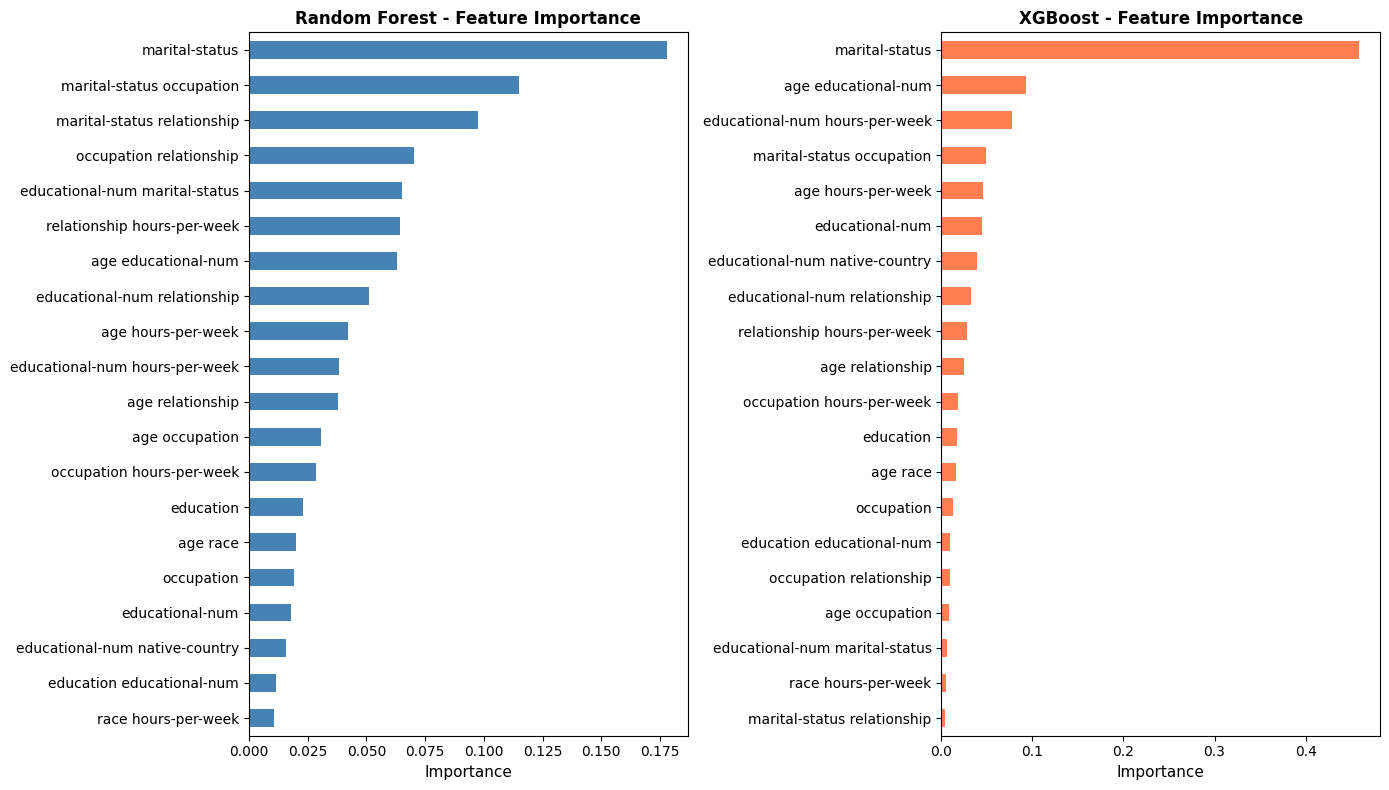

Feature importance plot saved as 'feature_importance.png'


In [28]:
# Feature Importance in Final Models

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Plot 1: Random Forest Feature Importance
rf_importances = pd.Series(rf_final.feature_importances_, 
                           index=X_train_reduced.columns).sort_values(ascending=True)
ax = axes[0]
rf_importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance', fontsize=11)

# Plot 2: XGBoost Feature Importance
xgb_importances = pd.Series(xgb_final.feature_importances_, 
                            index=X_train_reduced.columns).sort_values(ascending=True)
ax = axes[1]
xgb_importances.plot(kind='barh', ax=ax, color='coral')
ax.set_title('XGBoost - Feature Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance', fontsize=11)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("Feature importance plot saved as 'feature_importance.png'")

SHAP Summary Plot (Bar)...


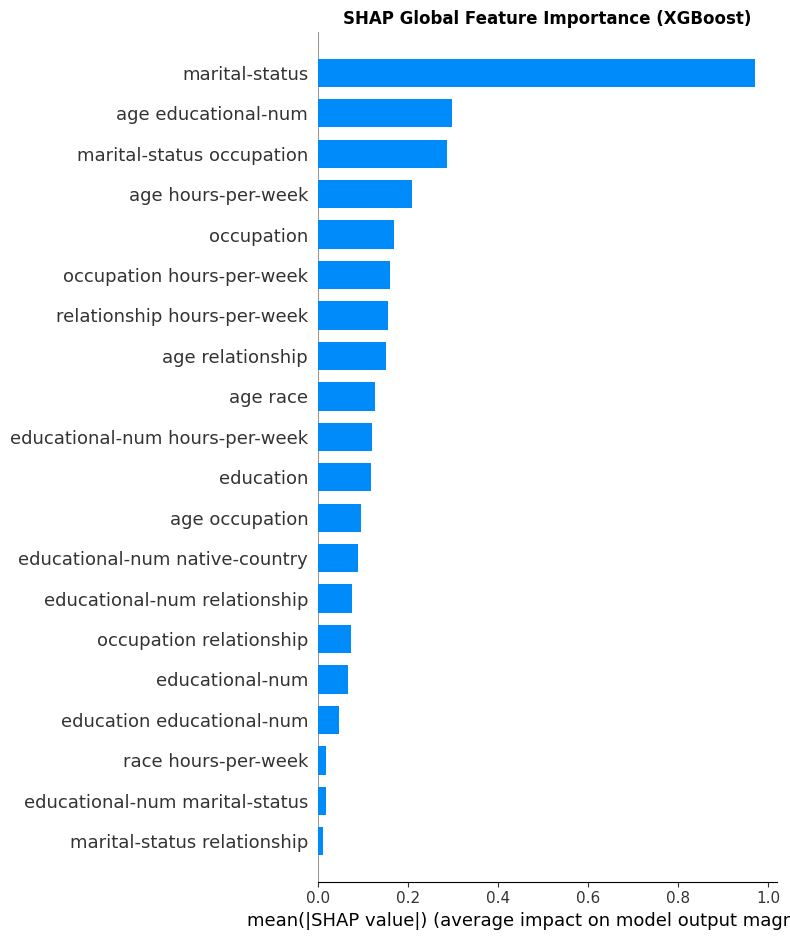

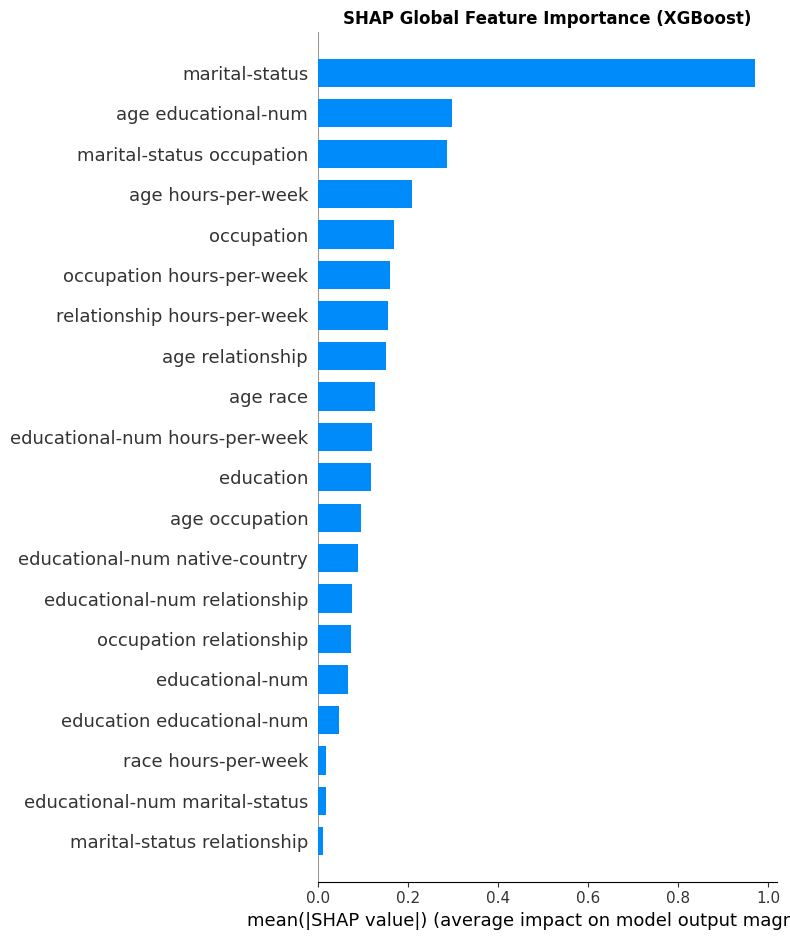

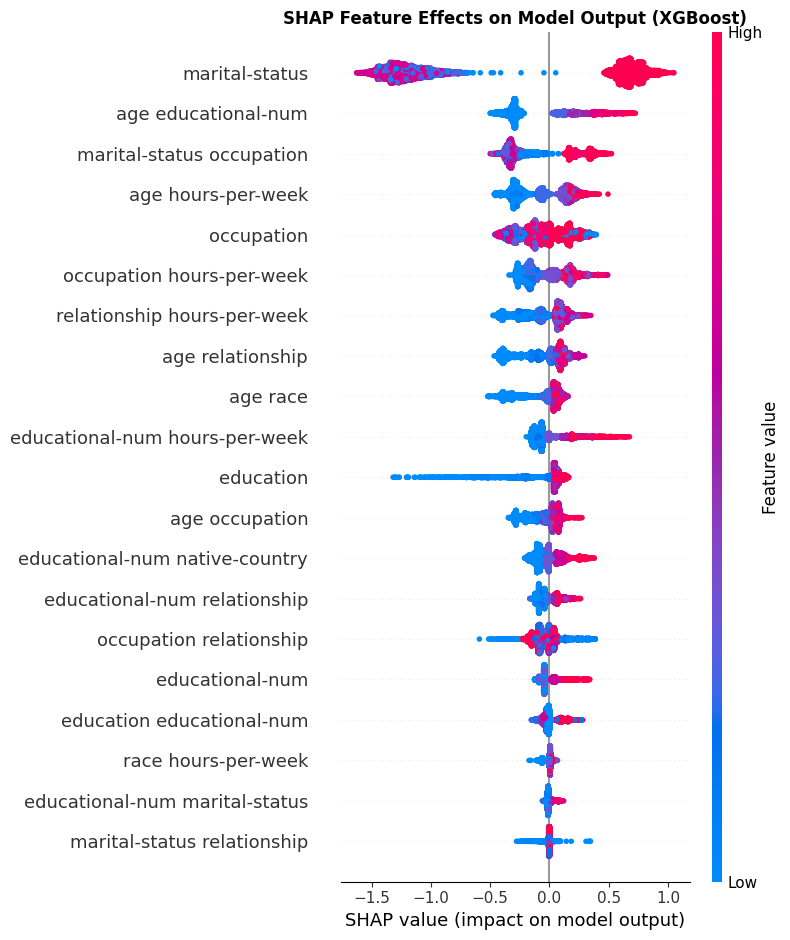

In [29]:
# SHAP Analysis for Model Interpretability
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test_reduced)

# Global feature importance
print("SHAP Summary Plot (Bar)...")
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_reduced, plot_type="bar", show=False)
plt.title('SHAP Global Feature Importance (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=100, bbox_inches='tight')
plt.show()
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_reduced, plot_type="bar", show=False)
plt.title('SHAP Global Feature Importance (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=100, bbox_inches='tight')
plt.show()

fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_reduced, show=False)
plt.title('SHAP Feature Effects on Model Output (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=100, bbox_inches='tight')
plt.show()

### Results Evaluation and Analysis

Feature Reduction: Reduced from 65 features to 20 features using ensemble feature selection combining model-based importance, permutation importance, and statistical significance.

Model Tuning: Hyperparameters optimized using GridSearchCV (Random Forest) and RandomizedSearchCV (XGBoost).

Stacking: Implemented using 5-fold out-of-fold predictions with Logistic Regression meta learner.

**Key Findings**:
- Feature reduction maintained performance while improving interpretability
- Tuning provided meaningful improvements for both models
- Stacking combined model predictions with learned meta learner weights
- Age, education, and work hours emerged as top predictors
- SHAP analysis revealed non-linear feature interactions

In [30]:
# Generate Analysis Summary with Actual Results

print("=" * 80)
print("FINAL ANALYSIS SUMMARY")
print("=" * 80)

print("\n### FEATURE REDUCTION IMPACT ###\n")

print(f"Baseline features (before expansion): 13")
print(f"Expanded features (with interactions): {X_train_poly_df.shape[1]}")
print(f"Selected features (final): {len(top_features)}")
print(f"Reduction percentage: {(1 - len(top_features)/X_train_poly_df.shape[1]) * 100:.1f}%")

print(f"\nPerformance with all features:")
print(f"  Random Forest:  {balanced_accuracy_score(y_test, rf_preds_poly):.4f} balanced accuracy")
print(f"  XGBoost:        {balanced_accuracy_score(y_test, xgb_preds_poly):.4f} balanced accuracy")

print(f"\nPerformance with reduced features (20 features):")
print(f"  RF (baseline):  {balanced_accuracy_score(y_test, rf_baseline_preds):.4f}")
print(f"  XGB (baseline): {balanced_accuracy_score(y_test, xgb_baseline_preds):.4f}")
print(f"  RF (tuned):     {balanced_accuracy_score(y_test, rf_final_preds):.4f}")
print(f"  XGB (tuned):    {balanced_accuracy_score(y_test, xgb_final_preds):.4f}")

print(f"\nTuning Improvements:")
print(f"  RF improvement:  {(rf_tuned_acc - rf_baseline_acc):.4f}")
print(f"  XGB improvement: {(xgb_tuned_acc - xgb_baseline_acc):.4f}")

print(f"\n### STACKING ANALYSIS ###\n")
print(f"Stacked model balanced accuracy: {balanced_accuracy_score(y_test, stacked_preds):.4f}")
print(f"Best individual model: {max(rf_tuned_acc, xgb_tuned_acc):.4f}")
print(f"Stacking improvement: {(balanced_accuracy_score(y_test, stacked_preds) - max(rf_tuned_acc, xgb_tuned_acc)):.4f}")

print(f"\nMeta-learner weights (probabilities):")
print(f"  Random Forest weight: {meta_model.coef_[0, 0]:.4f}")
print(f"  XGBoost weight:       {meta_model.coef_[0, 1]:.4f}")

print(f"\n### TOP 10 IMPORTANT FEATURES ###\n")
for i, feat in enumerate(top_features[:10], 1):
    print(f"{i:2d}. {feat}")

FINAL ANALYSIS SUMMARY

### FEATURE REDUCTION IMPACT ###

Baseline features (before expansion): 13
Expanded features (with interactions): 65
Selected features (final): 20
Reduction percentage: 69.2%

Performance with all features:
  Random Forest:  0.7817 balanced accuracy
  XGBoost:        0.7997 balanced accuracy

Performance with reduced features (20 features):
  RF (baseline):  0.7766
  XGB (baseline): 0.8021
  RF (tuned):     0.8050
  XGB (tuned):    0.8095

Tuning Improvements:
  RF improvement:  0.0284
  XGB improvement: 0.0074

### STACKING ANALYSIS ###

Stacked model balanced accuracy: 0.7642
Best individual model: 0.8095
Stacking improvement: -0.0454

Meta-learner weights (probabilities):
  Random Forest weight: 0.9717
  XGBoost weight:       4.6776

### TOP 10 IMPORTANT FEATURES ###

 1. age educational-num
 2. marital-status
 3. age relationship
 4. educational-num hours-per-week
 5. marital-status occupation
 6. age hours-per-week
 7. occupation relationship
 8. age occupa